## Prerequisites

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [19]:
df = pd.read_csv("uber.csv")

In [14]:
df.dropna(inplace=True)

In [15]:
df.drop_duplicates(inplace=True)

## Task-1

In [26]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')

numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()
print(corr_matrix)

                   Unnamed: 0  fare_amount  pickup_longitude  pickup_latitude  \
Unnamed: 0           1.000000     0.000589          0.000230        -0.000341   
fare_amount          0.000589     1.000000          0.010457        -0.008481   
pickup_longitude     0.000230     0.010457          1.000000        -0.816461   
pickup_latitude     -0.000341    -0.008481         -0.816461         1.000000   
dropoff_longitude    0.000270     0.008986          0.833026        -0.774787   
dropoff_latitude     0.000271    -0.011014         -0.846324         0.702367   
passenger_count      0.002257     0.010150         -0.000414        -0.001560   

                   dropoff_longitude  dropoff_latitude  passenger_count  
Unnamed: 0                  0.000270          0.000271         0.002257  
fare_amount                 0.008986         -0.011014         0.010150  
pickup_longitude            0.833026         -0.846324        -0.000414  
pickup_latitude            -0.774787          0.702367 

<Axes: >

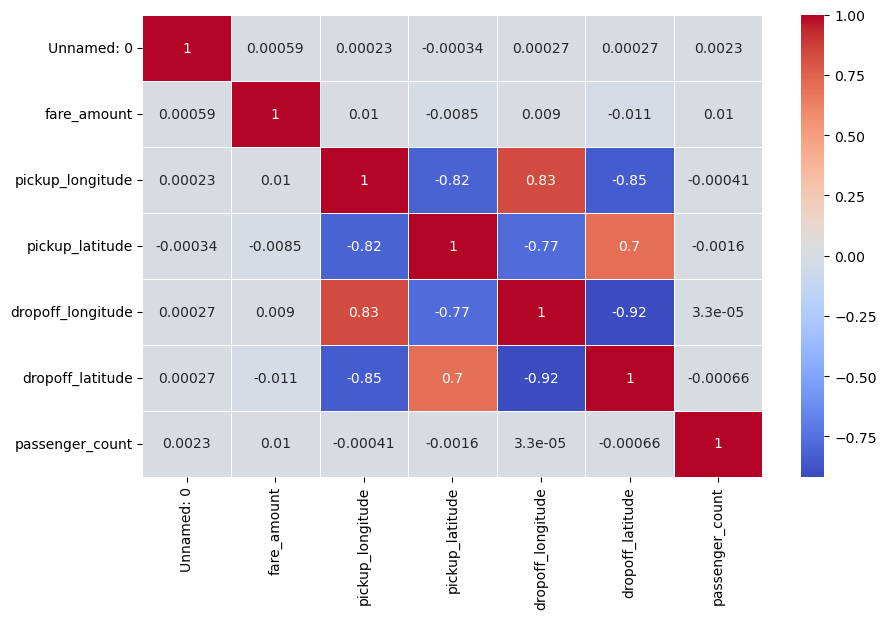

In [100]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

## Task-2

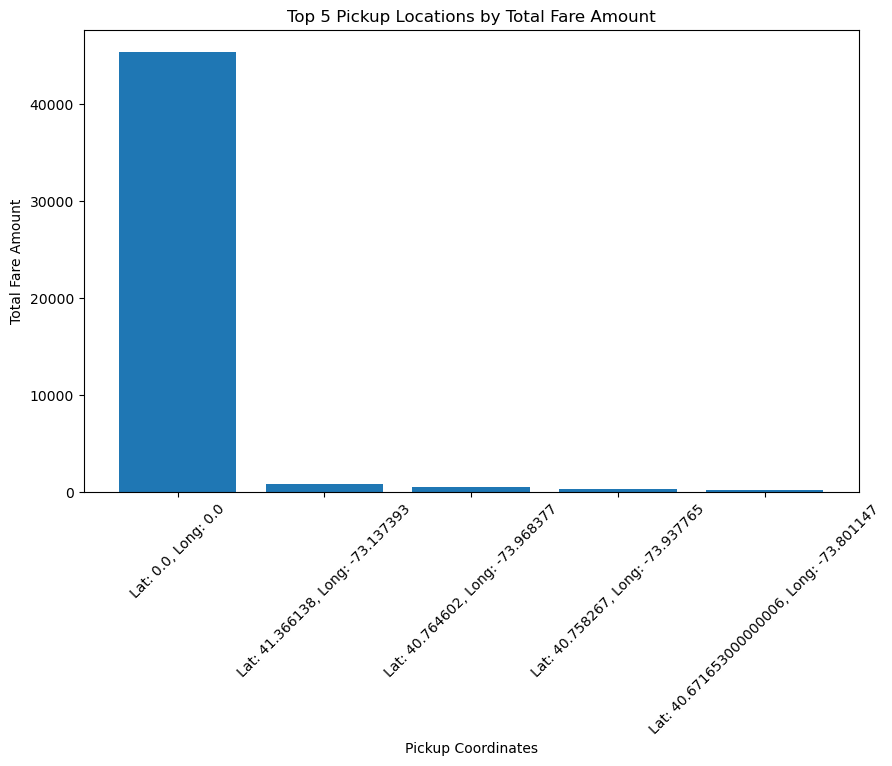

In [54]:
top_5_pickup_fares = df.groupby(['pickup_latitude', 'pickup_longitude'])['fare_amount'].sum().sort_values(ascending=False).head(5)

top_5_pickup_fares.index = top_5_pickup_fares.index.map(lambda x: "Lat: {}, Long: {}".format(x[0], x[1]))

plt.figure(figsize=(10,6))
plt.bar(x=top_5_pickup_fares.index, height=top_5_pickup_fares.values)
plt.title('Top 5 Pickup Locations by Total Fare Amount')
plt.xlabel('Pickup Coordinates')
plt.ylabel('Total Fare Amount')
plt.xticks(rotation=45)
plt.show()

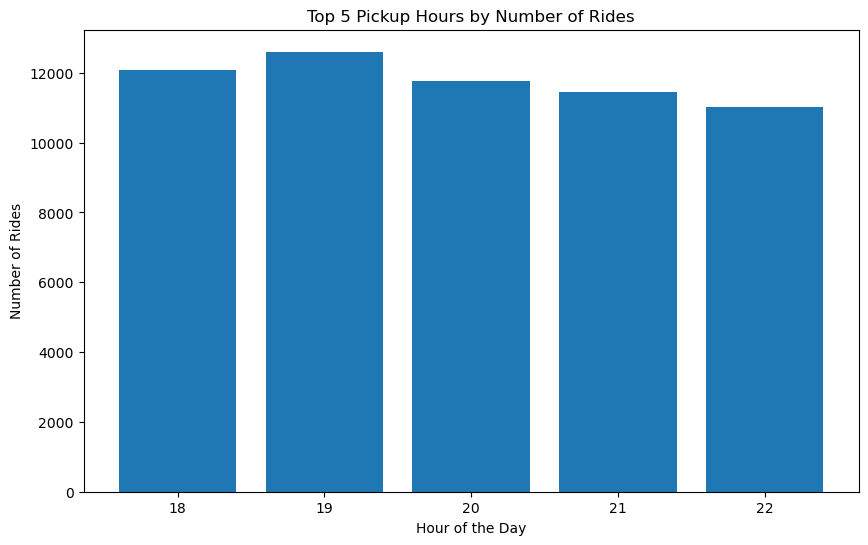

In [52]:
df['hour'] = df['pickup_datetime'].dt.hour

hours_rides = df.groupby('hour').size().sort_values(ascending=False).head(5)

plt.figure(figsize=(10,6))
plt.bar(x=top_5_hours_rides.index, height=top_5_hours_rides.values)
plt.title('Top 5 Pickup Hours by Number of Rides')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Rides')
plt.show()

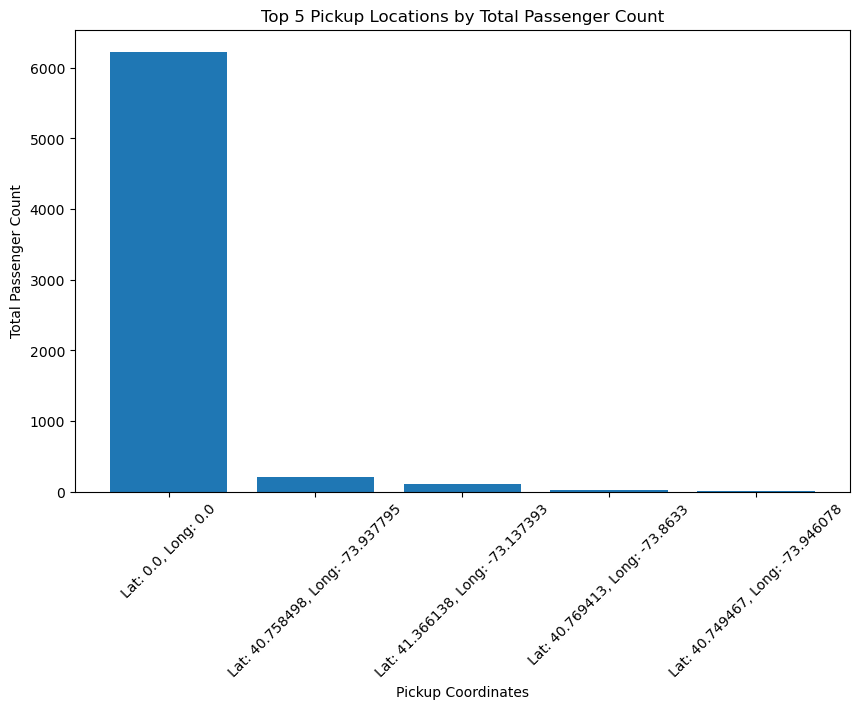

In [56]:
top_5_pickup_passenger_count = df.groupby(['pickup_latitude', 'pickup_longitude'])['passenger_count'].sum().sort_values(ascending=False).head(5)

top_5_pickup_passenger_count.index = top_5_pickup_passenger_count.index.map(lambda x: "Lat: {}, Long: {}".format(x[0], x[1]))

plt.figure(figsize=(10,6))
plt.bar(x=top_5_pickup_passenger_count.index.astype(str), height=top_5_pickup_passenger_count.values)
plt.title('Top 5 Pickup Locations by Total Passenger Count')
plt.xlabel('Pickup Coordinates')
plt.ylabel('Total Passenger Count')
plt.xticks(rotation=45)
plt.show()

## Horizontal Bar Plot

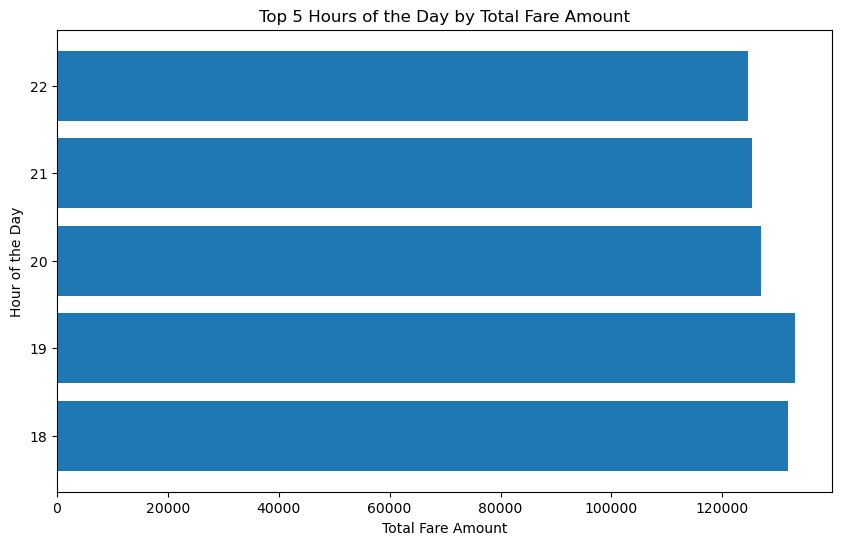

In [57]:
top_5_hours_fare = df.groupby('hour')['fare_amount'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(10,6))
plt.barh(y=top_5_hours_fare.index, width=top_5_hours_fare.values)
plt.title('Top 5 Hours of the Day by Total Fare Amount')
plt.xlabel('Total Fare Amount')
plt.ylabel('Hour of the Day')
plt.show()

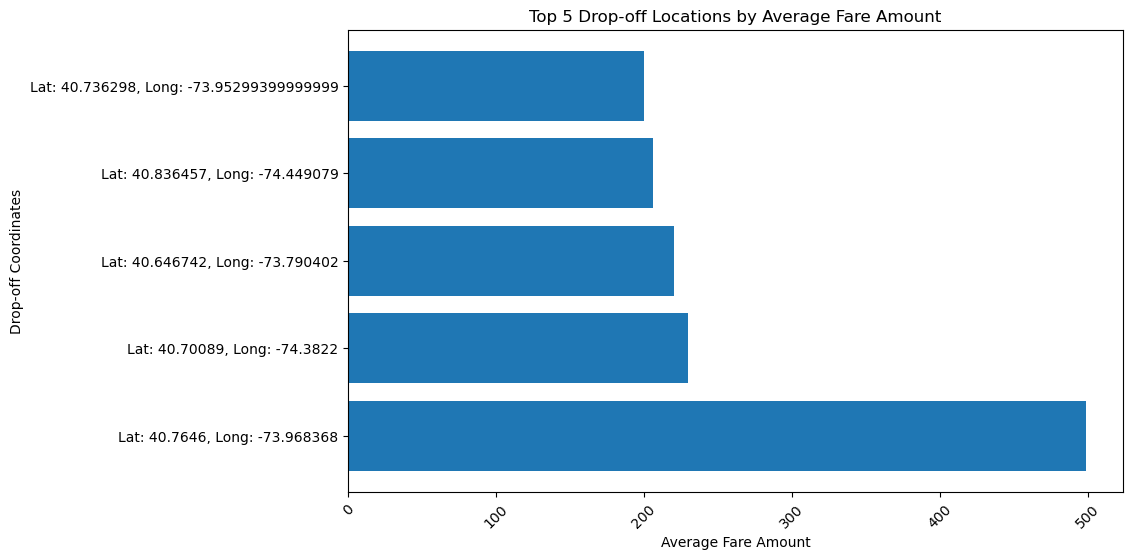

In [59]:
top_5_dropoff_avg_fare = df.groupby(['dropoff_latitude', 'dropoff_longitude'])['fare_amount'].mean().sort_values(ascending=False).head(5)

top_5_dropoff_avg_fare.index = top_5_dropoff_avg_fare.index.map(lambda x: "Lat: {}, Long: {}".format(x[0], x[1]))

plt.figure(figsize=(10,6))
plt.barh(y=top_5_dropoff_avg_fare.index.astype(str), width=top_5_dropoff_avg_fare.values)
plt.title('Top 5 Drop-off Locations by Average Fare Amount')
plt.xlabel('Average Fare Amount')
plt.ylabel('Drop-off Coordinates')
plt.xticks(rotation=45)
plt.show()

## Task-3

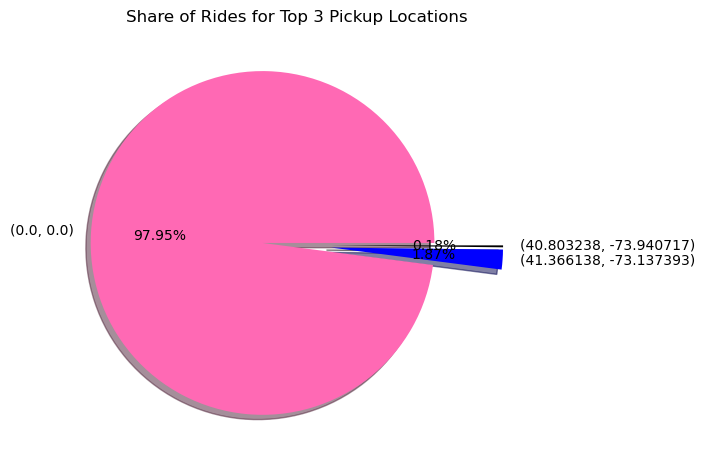

In [99]:
top_locations = df.groupby(['pickup_latitude', 'pickup_longitude']).size().sort_values(ascending=False).head(3)
top_locations.plot.pie(autopct='%.2f%%', explode=[0.2, 0.2, 0.2], shadow=True, colors=['hotpink', 'b', 'black'])
plt.title('Share of Rides for Top 3 Pickup Locations')
plt.tight_layout()
plt.show()

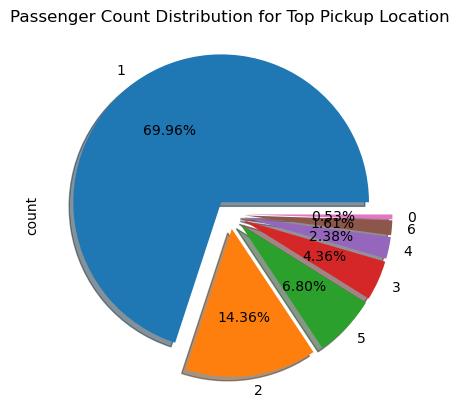

In [97]:
top_pickup = df[df['pickup_latitude'] == top_locations.index[0][0]]
top_pickup_passenger_count = top_pickup['passenger_count'].value_counts()
top_pickup_passenger_count.plot.pie(autopct='%.2f%%', shadow=True, explode=len(top_pickup_passenger_count)*[0.1])
plt.title('Passenger Count Distribution for Top Pickup Location')
plt.show()


## Task-4

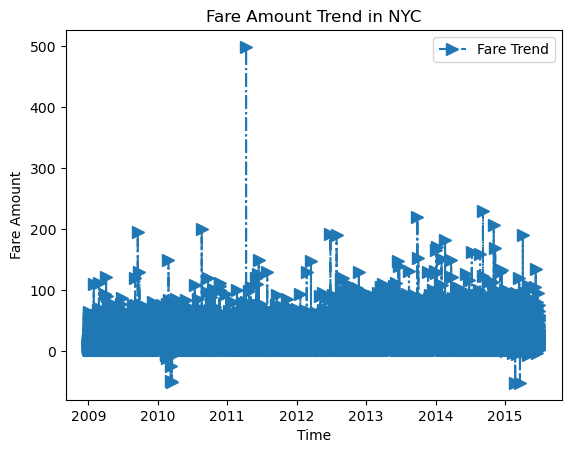

In [75]:
nyc_df = df[(df['pickup_latitude'] > 40.5) & (df['pickup_latitude'] < 41) & 
            (df['pickup_longitude'] > -74.5) & (df['pickup_longitude'] < -73.5)]

fare_trend = nyc_df.groupby('pickup_datetime')['fare_amount'].aggregate('sum').reset_index()
fare_trend['pickup_datetime'] = pd.to_datetime(fare_trend['pickup_datetime'])
fare_trend.set_index('pickup_datetime', inplace=True)

plt.plot(fare_trend.index, fare_trend['fare_amount'], linestyle='dashdot', marker='>', markersize=8, label='Fare Trend')
plt.title('Fare Amount Trend in NYC')
plt.xlabel('Time')
plt.ylabel('Fare Amount')
plt.legend()
plt.show()

In [104]:
max_fare_hour = fare_trend.groupby('hour')['fare_amount'].sum().idxmax()
max_fare = fare_trend.groupby('hour')['fare_amount'].sum().max()
print("Hour at which highest cumulative fair amount is achieved:",max_fare_hour)
print("Highest Cumulative Fair Amount:",max_fare)

Hour at which highest cumulative fair amount is achieved: 19
Highest Cumulative Fair Amount: 129834.81


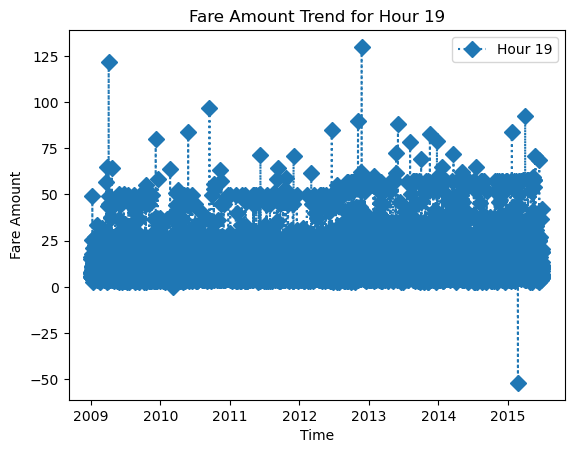

In [88]:
fare_trend['hour'] = fare_trend.index.hour
highest_hour_fare = fare_trend[fare_trend.index.hour == max_fare_hour]
plt.plot(highest_hour_fare.index, highest_hour_fare['fare_amount'], linestyle='dotted', marker='D', markersize=8, label=f'Hour {max_fare_hour}')
plt.title(f'Fare Amount Trend for Hour {max_fare_hour}')
plt.xlabel('Time')
plt.ylabel('Fare Amount')
plt.legend()
plt.show()

## Task-5

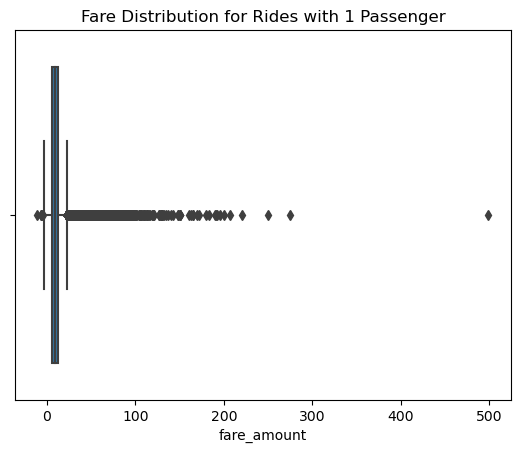

In [77]:
sns.boxplot(data=df[df['passenger_count'] == 1], x='fare_amount')
plt.title('Fare Distribution for Rides with 1 Passenger')
plt.show()

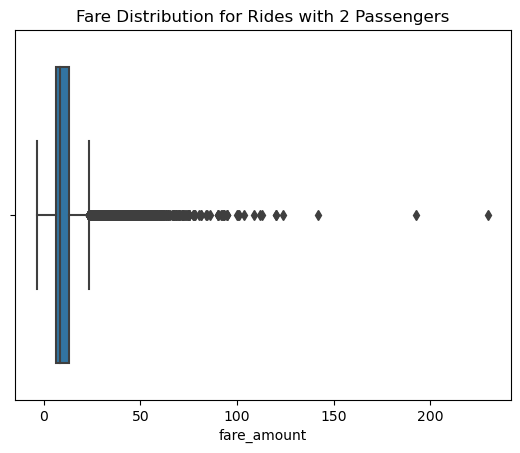

In [78]:
sns.boxplot(data=df[df['passenger_count'] == 2], x='fare_amount')
plt.title('Fare Distribution for Rides with 2 Passengers')
plt.show()

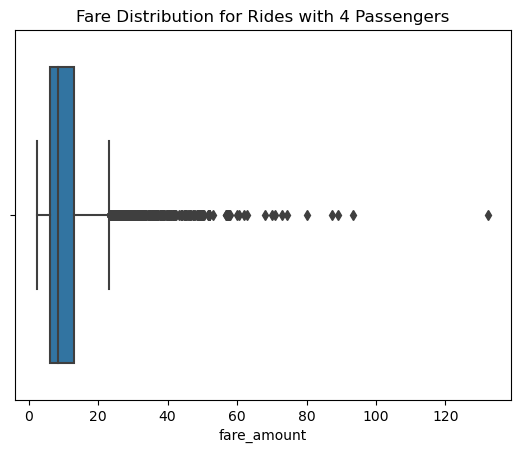

In [81]:
sns.boxplot(data=df[df['passenger_count'] == 4], x='fare_amount')
plt.title('Fare Distribution for Rides with 4 Passengers')
plt.show()

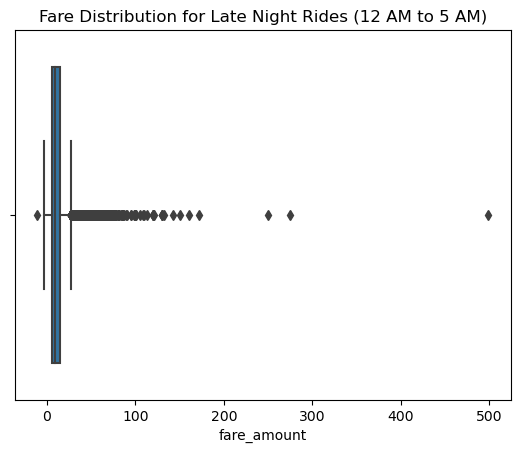

In [82]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
late_night_rides = df[(df['pickup_datetime'].dt.hour >= 0) & (df['pickup_datetime'].dt.hour <= 5)]
sns.boxplot(data=late_night_rides, x='fare_amount')
plt.title('Fare Distribution for Late Night Rides (12 AM to 5 AM)')
plt.show()